<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">             <tr>
                <td  style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>Armin Ghasemi</b><br><br>810100198</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> ML </b><br><br>Final_Project</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>  </b><br><br></i></font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
           </tr>
        </table>
    </div>
</div>

# 🆔 Speaker Identification: Multi-Class Biometric Recognition
### Identifying Individuals from Voice Fingerprints using Ensemble & Deep Learning

> **University:** University of Tehran
> **Course:** Machine Learning
> **Project:** Final Capstone Project - Part D
> **Task:** Multi-Class Classification (N-Way Speaker ID)

---

## 🎯 Objective
Unlike gender classification, **Speaker Identification** is a much harder task requiring the model to distinguish between specific individuals. In this notebook, we simulate a biometric system by selecting a subset of **6 random speakers** from our dataset and training models to identify them based on their unique vocal characteristics (Timbre, Pitch, etc.).

## ⚙️ Workflow
1.  **Dynamic Data Loading:** Randomly selecting $N=6$ speakers to create a balanced "N-way" classification dataset.
2.  **Feature Engineering:** Ranking features using `SelectKBest` and `RandomForest` to find the most unique identifiers per person.
3.  **Model Benchmarking:** Comparing **SVM, KNN, Random Forest**, and a **PyTorch MLP** on the multi-class problem.

### Imports

In [ ]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, label_binarize
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# Global Path Configuration
# ==========================================
BASE_DIR = os.getcwd()
# Pointing to: ./data/feature_stores/speaker_id_data/
DATA_FOLDER = os.path.join(BASE_DIR, "data", "feature_stores", "speaker_id_data")

# Check if directory exists
if not os.path.exists(DATA_FOLDER):
    print(f"WARNING: Directory not found at {DATA_FOLDER}")
    # Fallback for creating dummy folder structure if running first time
    os.makedirs(DATA_FOLDER, exist_ok=True)

print(f"Data Source: {DATA_FOLDER}")
# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

### Data loading, preprocessing and splitting

In [ ]:
# --- 1. Load & Select Speakers ---

# Get all CSV files
all_files = [f for f in os.listdir(DATA_FOLDER) if f.endswith(".csv")]

if len(all_files) < 2:
    print("Not enough files found. Please run the Preprocessing notebook first.")
    # creating dummy list to avoid crash if folder is empty
    random_files = []
else:
    # Select 6 random speakers (Reproducible due to seed=42)
    num_speakers = min(6, len(all_files))
    random_files = random.sample(all_files, num_speakers)
    print(f"Selected Speakers: {random_files}")

# --- 2. Load Dataframes ---
data_frames = {}
for file in random_files:
    file_path = os.path.join(DATA_FOLDER, file)
    data_frames[file] = pd.read_csv(file_path)

if len(data_frames) > 0:
    # --- 3. Balance Classes ---
    # Find the minimum number of rows among selected files to ensure balanced classes
    min_rows = min(df.shape[0] for df in data_frames.values())
    print(f"Balancing dataset: Limiting each speaker to {min_rows} samples.")

    train_data = pd.DataFrame()
    test_data = pd.DataFrame()

    for file, df in data_frames.items():
        # Downsample
        df_sampled = df.sample(n=min_rows, random_state=42).reset_index(drop=True)
        
        # Add a column for the label (using filename as ID initially)
        # We assume the file doesn't have a label column, or we want to use the filename
        # You used 'file_number' later, so let's create it from filename
        df_sampled['file_number'] = file.replace(".csv", "").replace("features_", "")

        # Split 75/25
        test_part = df_sampled.sample(frac=0.25, random_state=42)
        train_part = df_sampled.drop(test_part.index)

        test_data = pd.concat([test_data, test_part], ignore_index=True)
        train_data = pd.concat([train_data, train_part], ignore_index=True)

    # Cleanup: Drop unnecessary columns if they exist (based on your previous code)
    # Be careful with indices [0, -2]. Better to drop by name if possible.
    # Assuming column 0 is 'filename' or 'index'
    if train_data.shape[1] > 2:
        train_data = train_data.iloc[:, 1:] 
        test_data = test_data.iloc[:, 1:]

    print("Final Train Data Shape:", train_data.shape)
    print("Final Test Data Shape:", test_data.shape)

    # Shuffle
    train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)
    test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)

    train_data.head()
else:
    print("No data loaded.")

Train Data Shape: (360, 23)
Test Data Shape: (120, 23)


,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,...,MFCC_14,MFCC_15,MFCC_16,MFCC_17,MFCC_18,MFCC_19,MFCC_20,F0,ZCR,file_number
0,-232.54031,147.98233,-13.118067,58.654247,-14.823519,-8.364408,-3.201605,-33.884426,6.132317,-23.941555,...,-8.824066,-14.693646,-8.541819,0.125166,-12.065334,2.966096,0.120099,166.415337,0.050293,159403005
1,-244.19122,168.41928,-10.854153,37.265730,-20.356410,9.023574,-23.553951,-30.825640,14.866898,-18.533970,...,15.915089,-18.382679,-3.456117,2.317782,-7.853684,-2.141384,-4.948762,228.617442,0.046478,810103345
2,-227.42370,181.40868,-25.850876,22.350096,-20.919655,-16.974405,-9.058096,-31.065120,3.162095,-23.828037,...,-2.243911,-7.079553,-15.882124,4.876460,-8.193134,-3.746280,1.610818,180.515132,0.043823,159403005
3,-247.41803,172.93578,-15.551523,24.783669,-28.649350,-36.098137,-11.298650,-41.062630,-10.347518,3.540668,...,3.181677,-4.285287,-6.542435,4.137497,-6.528866,-14.168973,-1.179222,165.490377,0.053772,810103169
4,-280.08435,168.21811,15.614850,20.124400,-20.311308,-0.060346,19.954906,-9.757734,-4.584402,-4.782527,...,1.382585,0.267694,-2.408060,-3.958474,-6.017110,-10.491646,-5.411085,221.853206,0.069885,810103345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,-273.30344,147.15750,-22.439148,45.265540,-15.981695,-23.738224,-4.100941,-31.943527,-6.603371,-19.557137,...,-3.131200,-11.269508,-10.050086,1.392989,-17.211231,1.276314,8.640526,182.631267,0.046387,159403005
356,-250.92685,191.52548,-44.537050,29.554117,-19.015121,-36.288586,-5.693167,-28.980074,-8.294788,-3.639089,...,-0.462448,-2.387405,-6.216847,3.479832,0.343021,-1.757953,-5.770775,148.145539,0.072174,810103169
357,-131.41116,194.89944,-54.243603,65.723560,-18.774630,6.896465,11.646770,-17.098934,10.265738,-18.108793,...,1.169112,-7.551982,-3.114741,0.754023,-0.258563,-1.491808,-1.800362,140.204788,0.067352,810103317
358,-220.19826,175.58713,-39.389645,12.110619,-6.788301,-17.037590,-21.516815,-34.976593,2.952481,-16.554901,...,-1.545751,-6.774974,-17.514782,3.421937,-13.957775,-8.261676,8.069541,186.927900,0.045929,159403005


### encoding

In [54]:
label_encoder = LabelEncoder()

train_data['id_encoded'] = label_encoder.fit_transform(train_data['file_number'])
test_data['id_encoded'] = label_encoder.transform(test_data['file_number'])

test_data = test_data.drop('file_number', axis=1)
train_data = train_data.drop('file_number', axis=1)
                           
train_data


,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,...,MFCC_14,MFCC_15,MFCC_16,MFCC_17,MFCC_18,MFCC_19,MFCC_20,F0,ZCR,id_encoded
0,-232.54031,147.98233,-13.118067,58.654247,-14.823519,-8.364408,-3.201605,-33.884426,6.132317,-23.941555,...,-8.824066,-14.693646,-8.541819,0.125166,-12.065334,2.966096,0.120099,166.415337,0.050293,0
1,-244.19122,168.41928,-10.854153,37.265730,-20.356410,9.023574,-23.553951,-30.825640,14.866898,-18.533970,...,15.915089,-18.382679,-3.456117,2.317782,-7.853684,-2.141384,-4.948762,228.617442,0.046478,3
2,-227.42370,181.40868,-25.850876,22.350096,-20.919655,-16.974405,-9.058096,-31.065120,3.162095,-23.828037,...,-2.243911,-7.079553,-15.882124,4.876460,-8.193134,-3.746280,1.610818,180.515132,0.043823,0
3,-247.41803,172.93578,-15.551523,24.783669,-28.649350,-36.098137,-11.298650,-41.062630,-10.347518,3.540668,...,3.181677,-4.285287,-6.542435,4.137497,-6.528866,-14.168973,-1.179222,165.490377,0.053772,1
4,-280.08435,168.21811,15.614850,20.124400,-20.311308,-0.060346,19.954906,-9.757734,-4.584402,-4.782527,...,1.382585,0.267694,-2.408060,-3.958474,-6.017110,-10.491646,-5.411085,221.853206,0.069885,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,-273.30344,147.15750,-22.439148,45.265540,-15.981695,-23.738224,-4.100941,-31.943527,-6.603371,-19.557137,...,-3.131200,-11.269508,-10.050086,1.392989,-17.211231,1.276314,8.640526,182.631267,0.046387,0
356,-250.92685,191.52548,-44.537050,29.554117,-19.015121,-36.288586,-5.693167,-28.980074,-8.294788,-3.639089,...,-0.462448,-2.387405,-6.216847,3.479832,0.343021,-1.757953,-5.770775,148.145539,0.072174,1
357,-131.41116,194.89944,-54.243603,65.723560,-18.774630,6.896465,11.646770,-17.098934,10.265738,-18.108793,...,1.169112,-7.551982,-3.114741,0.754023,-0.258563,-1.491808,-1.800362,140.204788,0.067352,2
358,-220.19826,175.58713,-39.389645,12.110619,-6.788301,-17.037590,-21.516815,-34.976593,2.952481,-16.554901,...,-1.545751,-6.774974,-17.514782,3.421937,-13.957775,-8.261676,8.069541,186.927900,0.045929,0


## Feature Distribution Analysis (KDE)
We visualize the Kernel Density Estimate (KDE) for various features. In Speaker ID, we expect to see multiple overlapping peaks or distinct shifts for different speakers, showing that each person has a unique "voice print."

KDE Curves for Train Data:


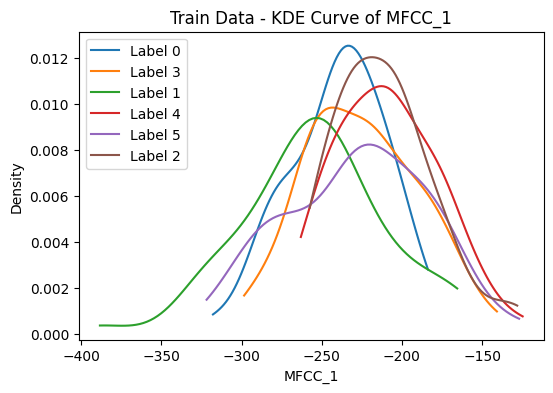

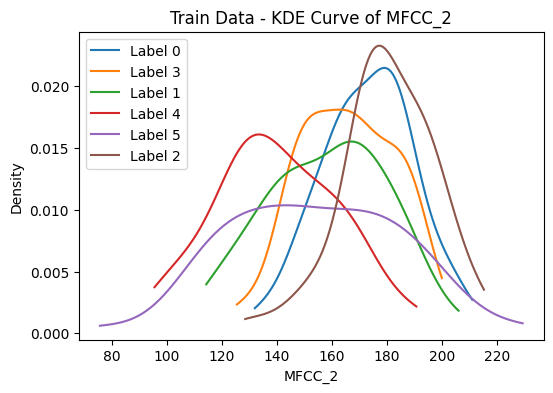

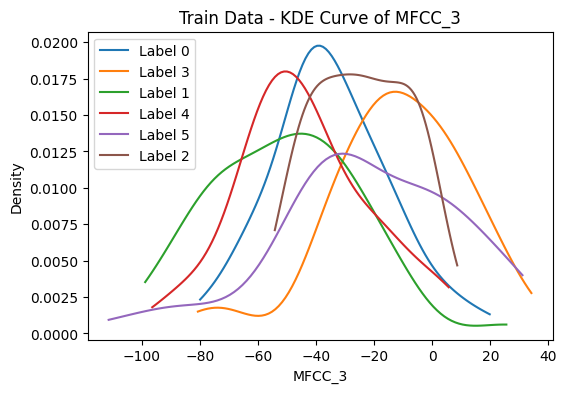

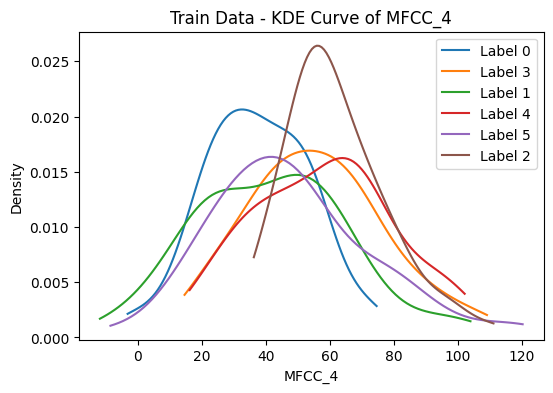

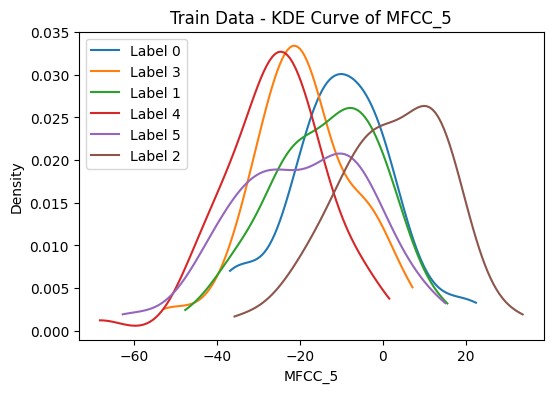

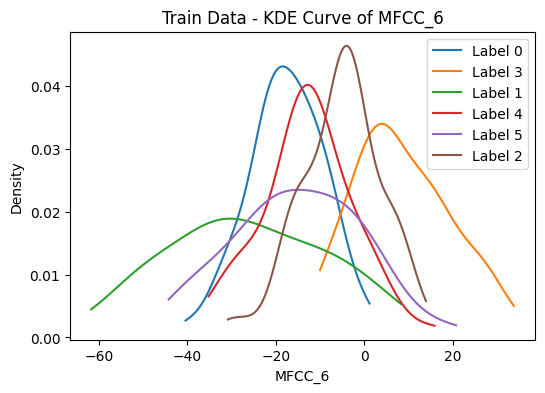

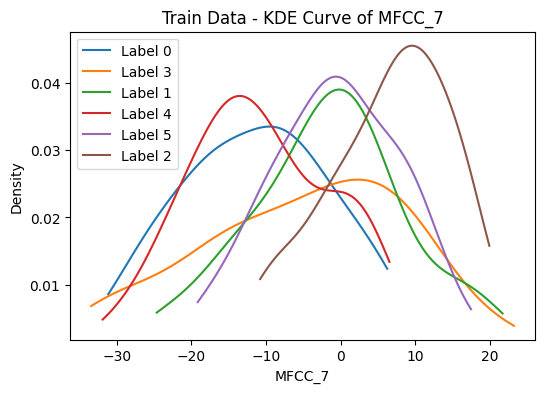

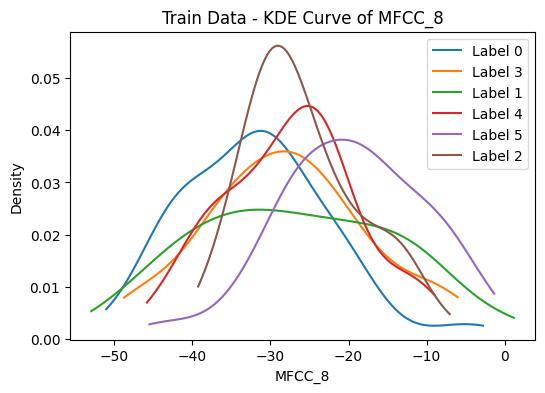

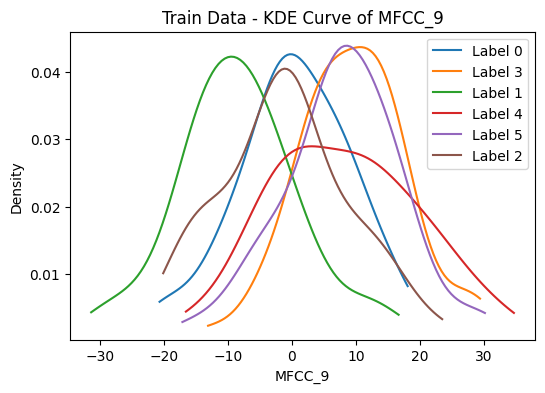

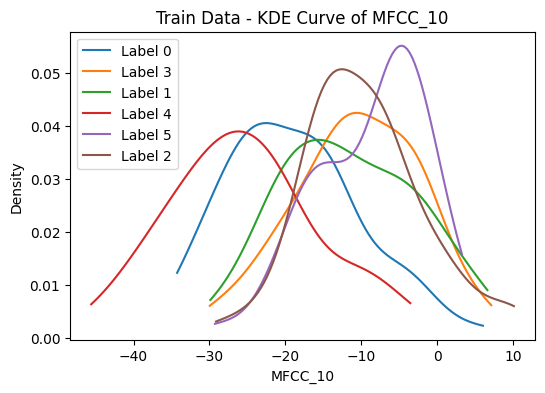

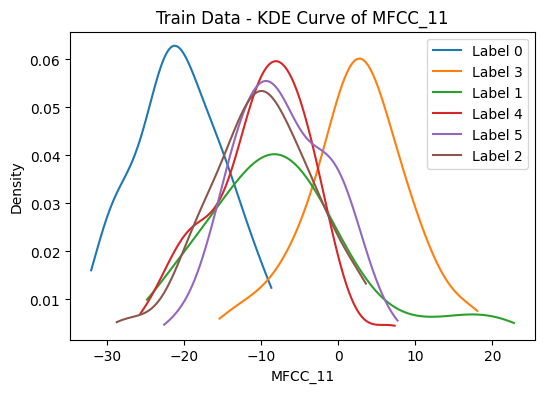

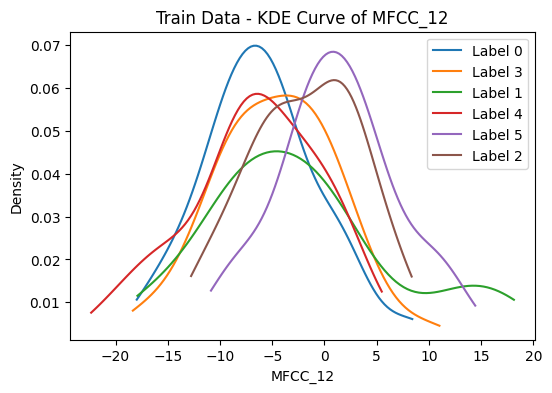

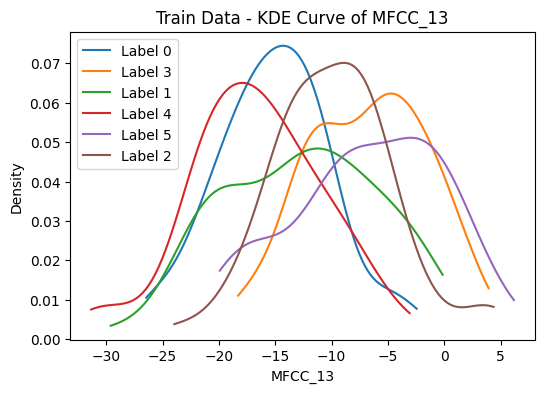

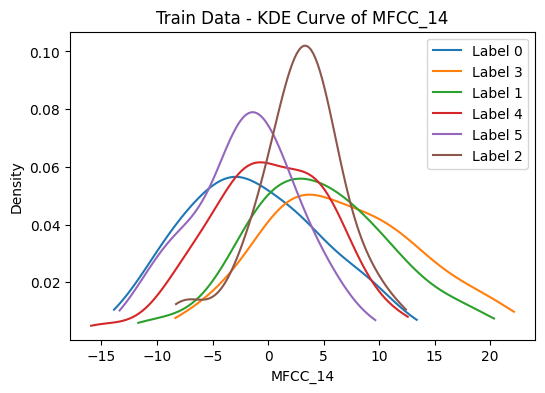

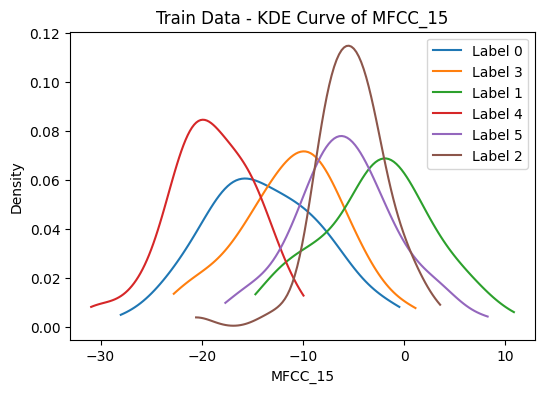

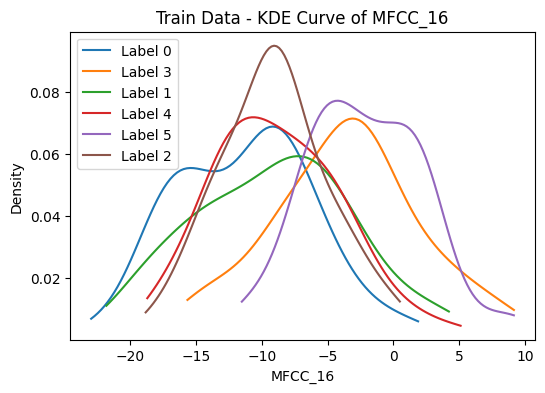

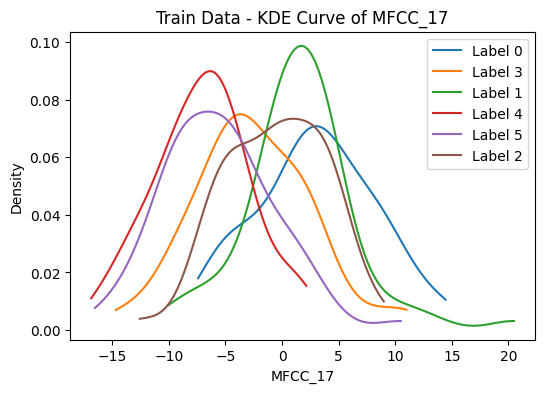

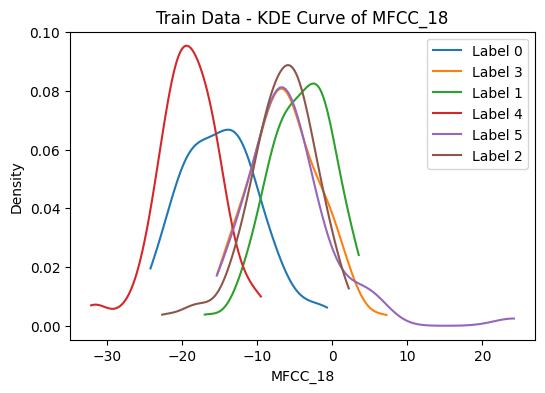

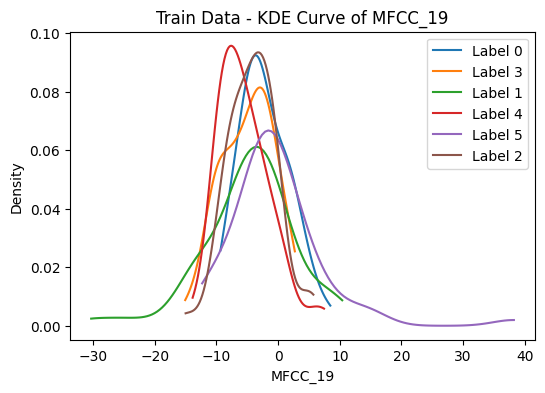

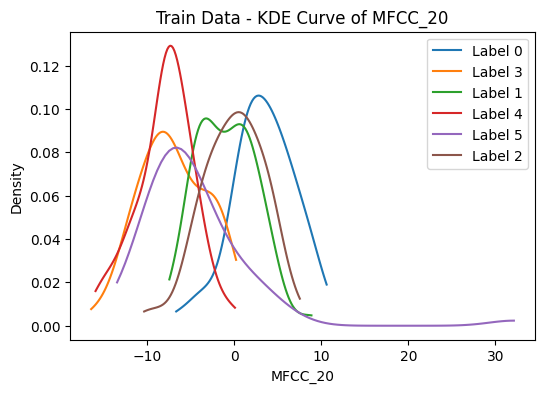

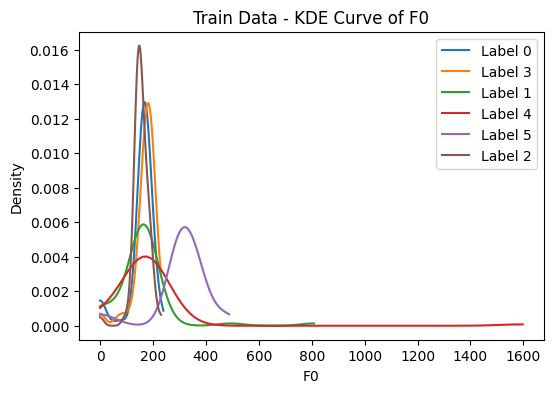

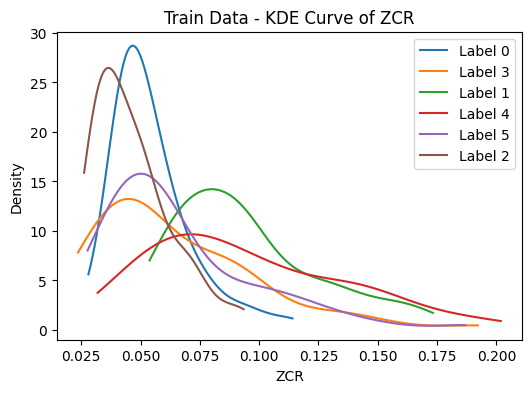

In [55]:
train_features = [col for col in train_data.columns if col not in [ 'id_encoded']]

print("KDE Curves for Train Data:")
for feature in train_features:
    plt.figure(figsize=(6, 4))
    for label in train_data['id_encoded'].unique():
        subset = train_data[train_data['id_encoded'] == label][feature]
        density = gaussian_kde(subset)
        x_vals = np.linspace(subset.min(), subset.max(), 100)
        plt.plot(x_vals, density(x_vals), label=f'Label {label}')
    plt.title(f'Train Data - KDE Curve of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend()
    plt.show()



## Feature Selection
Identifying which features are most "discriminative" for identifying a specific person. We use statistical tests (ANOVA) to drop features that do not vary significantly between speakers.## feature selection

### ANOVA Score 

In [56]:
X_train = train_data.drop(columns=['id_encoded']) 
y_train = train_data['id_encoded']  

X_test = test_data.drop(columns=['id_encoded']) 
y_test = test_data['id_encoded']  

selector = SelectKBest(score_func=f_classif, k='all')  
selector.fit(X_train, y_train)


feature_scores = pd.Series(selector.scores_, index=X_train.columns)
feature_scores = feature_scores.sort_values(ascending=True) 
print("Feature Scores (ascending):\n", feature_scores)


Feature Scores (ascending):
 MFCC_19     7.715440
MFCC_8      9.596041
MFCC_12    12.337708
MFCC_4     13.006216
MFCC_1     13.424831
F0         19.210781
MFCC_14    20.242209
MFCC_3     22.910699
MFCC_7     25.927119
MFCC_2     26.656258
ZCR        27.361604
MFCC_16    29.338934
MFCC_13    30.043105
MFCC_5     30.157329
MFCC_9     31.346157
MFCC_10    35.935417
MFCC_17    40.146222
MFCC_6     56.896882
MFCC_11    58.084428
MFCC_20    66.612074
MFCC_15    88.430195
MFCC_18    91.192271
dtype: float64


In [57]:

features_to_drop = feature_scores.index[:5]  
X_train = X_train.drop(columns=features_to_drop)
X_test = X_test.drop(columns=features_to_drop)
print("\nFeatures after dropping 5 least important:\n", X_train.columns.tolist())



Features after dropping 5 least important:
 ['MFCC_2', 'MFCC_3', 'MFCC_5', 'MFCC_6', 'MFCC_7', 'MFCC_9', 'MFCC_10', 'MFCC_11', 'MFCC_13', 'MFCC_14', 'MFCC_15', 'MFCC_16', 'MFCC_17', 'MFCC_18', 'MFCC_20', 'F0', 'ZCR']


### Random Forest

In [58]:
model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=True) 
print("Feature Importances (ascending):\n", feature_importances)


Feature Importances (ascending):
 MFCC_14    0.026679
MFCC_16    0.028525
MFCC_13    0.029708
MFCC_7     0.030500
MFCC_10    0.031033
MFCC_2     0.038651
MFCC_9     0.041201
MFCC_3     0.044203
MFCC_17    0.046405
MFCC_5     0.052973
ZCR        0.062478
MFCC_11    0.068809
MFCC_15    0.072630
MFCC_6     0.083639
MFCC_20    0.090765
MFCC_18    0.110143
F0         0.141658
dtype: float64


In [59]:
features_to_drop = feature_importances.index[:5] 
X_train = X_train.drop(columns=features_to_drop)
X_test = X_test.drop(columns=features_to_drop)
print("\nFeatures after dropping 5 least important:\n", X_train.columns.tolist())



Features after dropping 5 least important:
 ['MFCC_2', 'MFCC_3', 'MFCC_5', 'MFCC_6', 'MFCC_9', 'MFCC_11', 'MFCC_15', 'MFCC_17', 'MFCC_18', 'MFCC_20', 'F0', 'ZCR']


### Standardization and normalization

In [60]:
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

X_train_standardized = pd.DataFrame(scaler_standard.fit_transform(X_train), columns=X_train.columns)
X_train_normalized = pd.DataFrame(scaler_minmax.fit_transform(X_train), columns=X_train.columns)

X_test_standardized = pd.DataFrame(scaler_standard.transform(X_test), columns=X_test.columns)
X_test_normalized = pd.DataFrame(scaler_minmax.transform(X_test), columns=X_test.columns)

standardized_data = {
    'X_train_standardized': X_train_standardized,
    'X_test_standardized': X_test_standardized
}

normalized_data = {
    'X_train_normalized': X_train_normalized,
    'X_test_normalized': X_test_normalized
}
print(f"X_train:{X_train.shape}")
print(f"y_train:{y_train.shape}")
print(f"X_test:{X_test.shape}")
print(f"y_test:{y_test.shape}")
print(f"X_train_standardized:{X_train_standardized.shape}")
print(f"X_test_standardized:{X_test_standardized.shape}")
print(f"X_train_normalized:{X_train_normalized.shape}")
print(f"X_test_normalized:{X_test_normalized.shape}")

X_train:(360, 12)
y_train:(360,)
X_test:(120, 12)
y_test:(120,)
X_train_standardized:(360, 12)
X_test_standardized:(120, 12)
X_train_normalized:(360, 12)
X_test_normalized:(120, 12)


### Plotting standardized data

KDE Curves for Train Data:


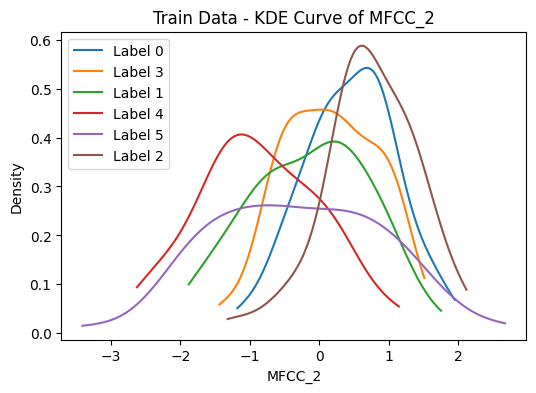

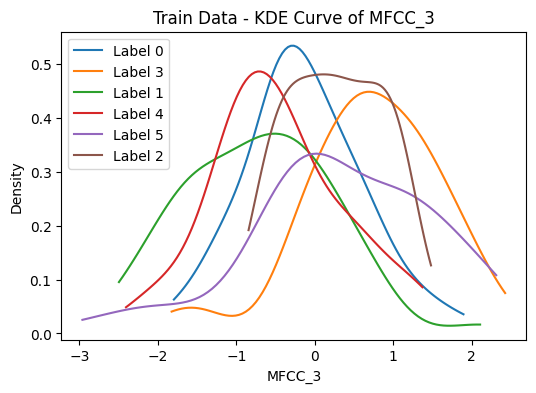

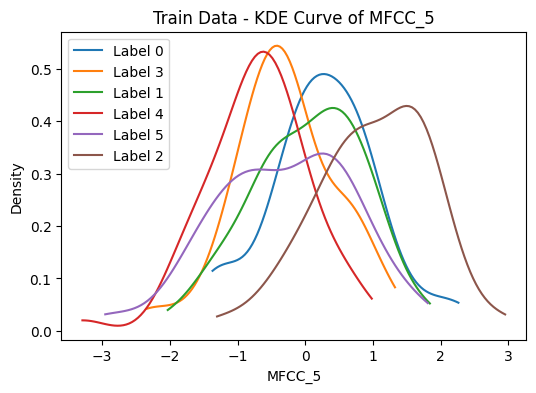

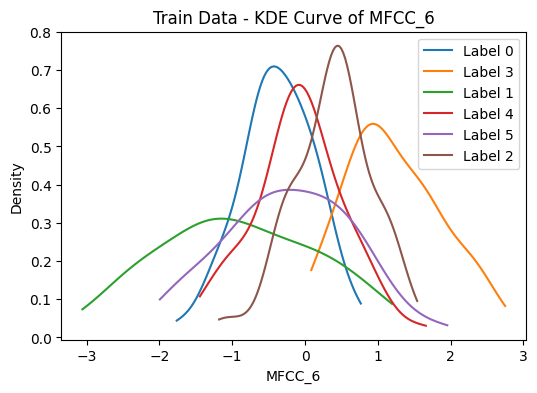

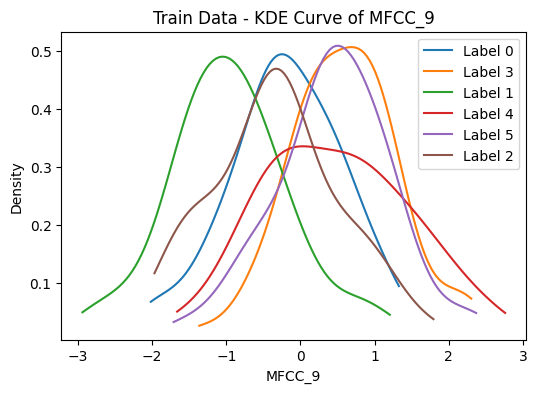

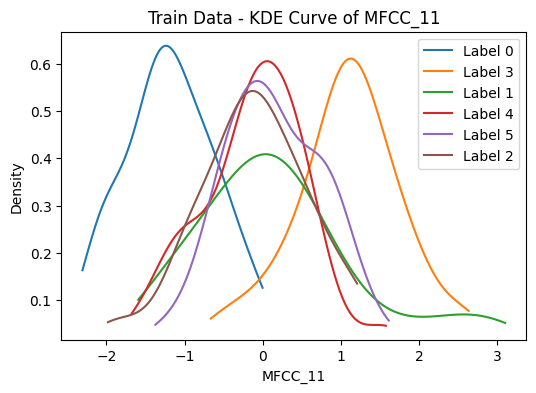

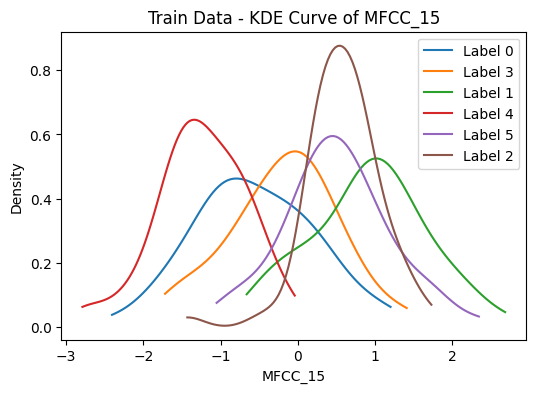

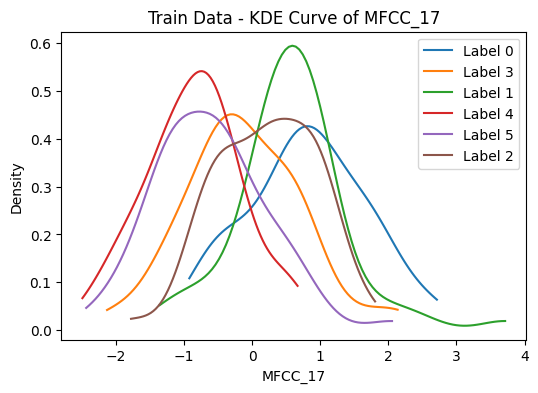

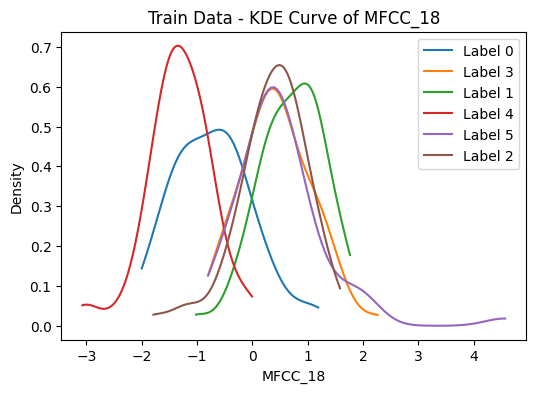

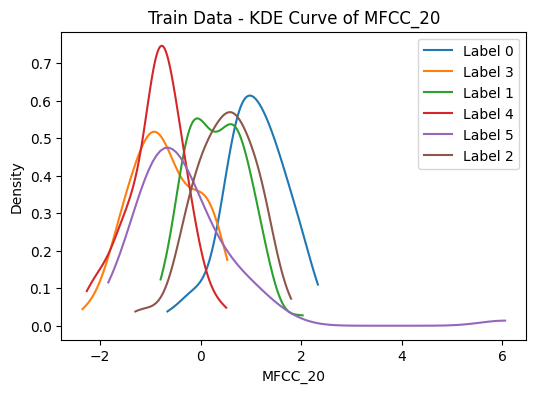

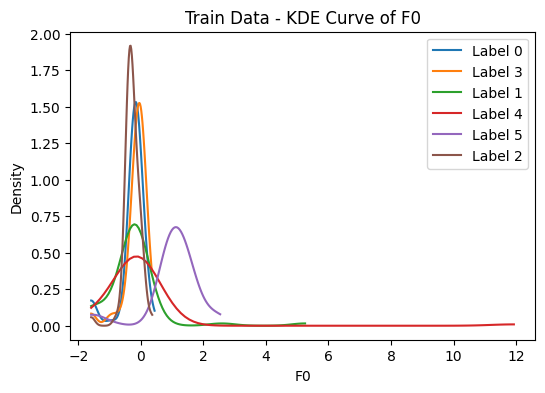

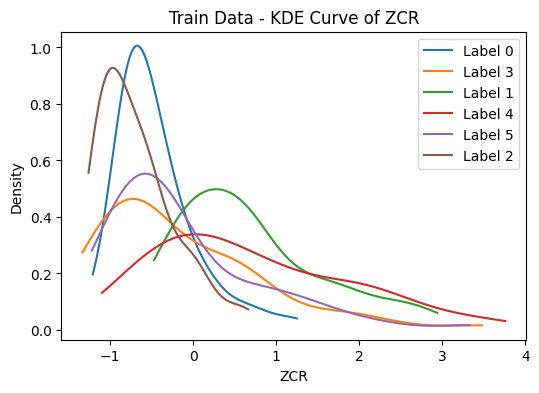

In [61]:
train_data = pd.concat([X_train_standardized, y_train], axis=1)
train_features = [col for col in train_data.columns if col not in [ 'id_encoded']]

print("KDE Curves for Train Data:")
for feature in train_features:
    plt.figure(figsize=(6, 4))
    for label in train_data['id_encoded'].unique():
        subset = train_data[train_data['id_encoded'] == label][feature]
        density = gaussian_kde(subset)
        x_vals = np.linspace(subset.min(), subset.max(), 100)
        plt.plot(x_vals, density(x_vals), label=f'Label {label}')
    plt.title(f'Train Data - KDE Curve of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend()
    plt.show()


### Plotting normalized data

KDE Curves for Train Data:


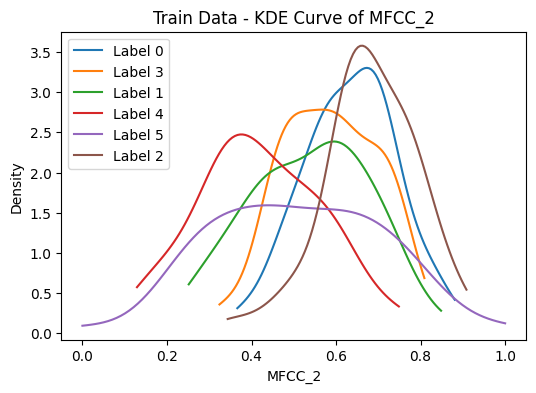

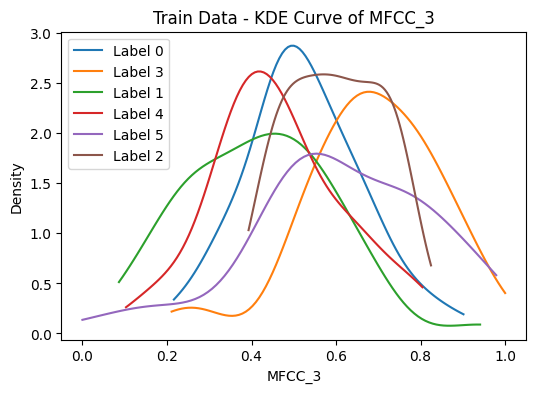

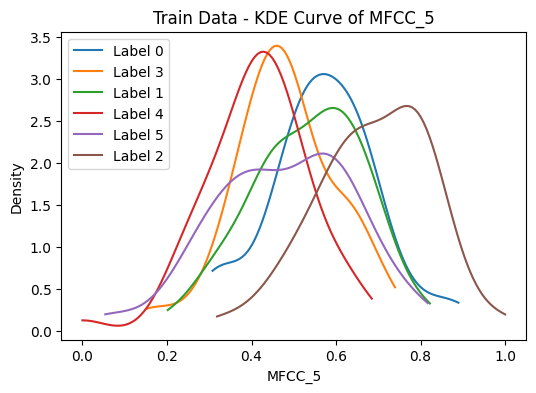

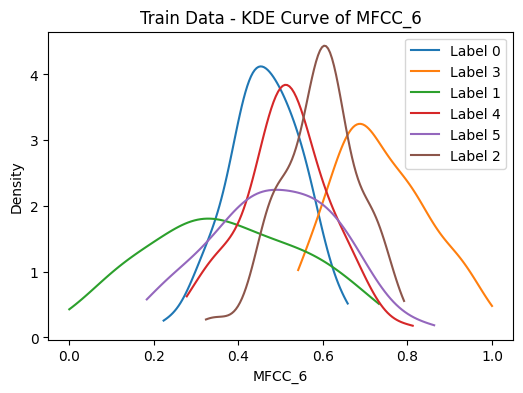

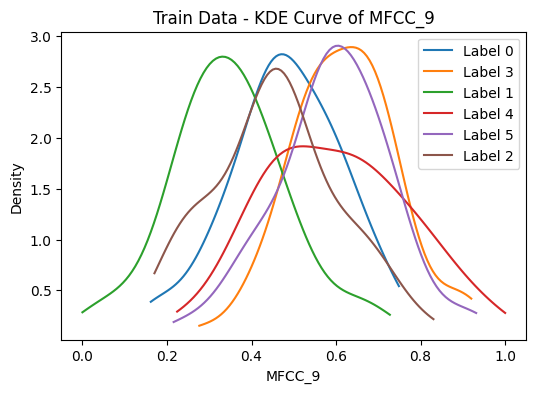

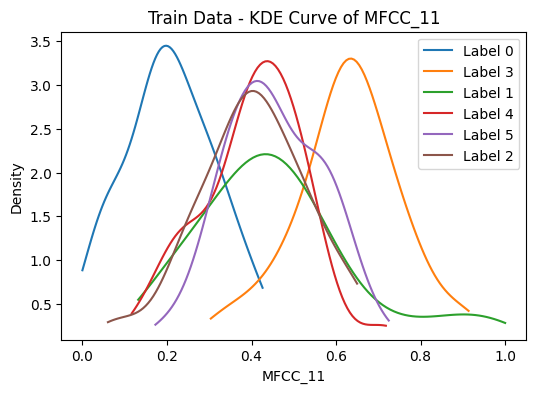

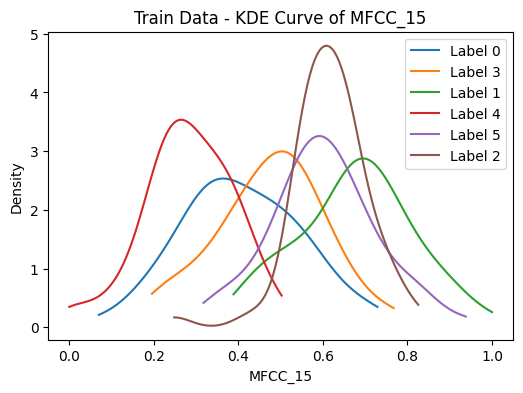

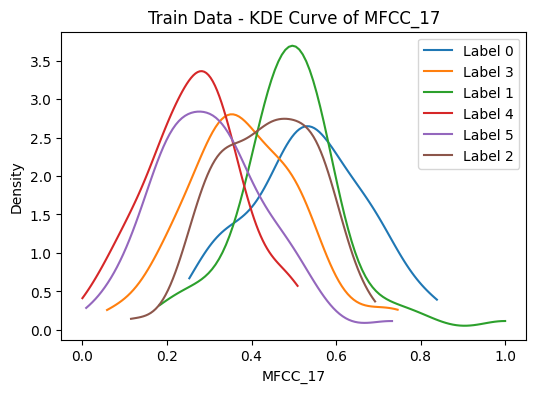

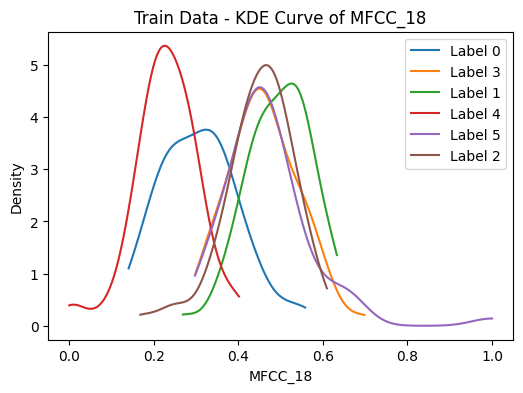

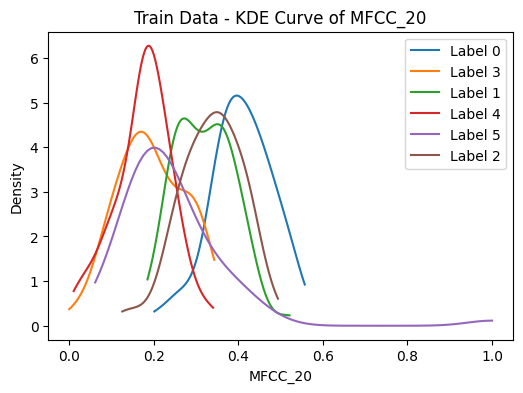

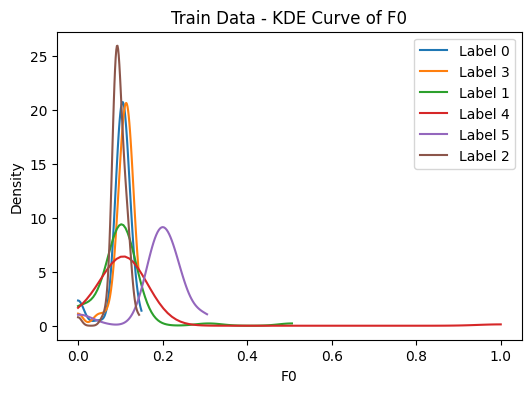

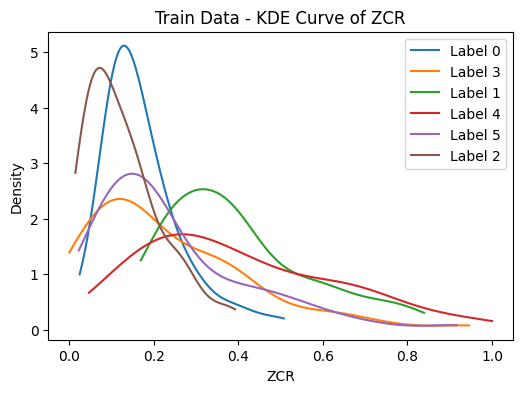

In [62]:
train_data = pd.concat([X_train_normalized, y_train], axis=1)
train_features = [col for col in train_data.columns if col not in [ 'id_encoded']]

print("KDE Curves for Train Data:")
for feature in train_features:
    plt.figure(figsize=(6, 4))
    for label in train_data['id_encoded'].unique():
        subset = train_data[train_data['id_encoded'] == label][feature]
        density = gaussian_kde(subset)
        x_vals = np.linspace(subset.min(), subset.max(), 100)
        plt.plot(x_vals, density(x_vals), label=f'Label {label}')
    plt.title(f'Train Data - KDE Curve of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend()
    plt.show()

## Support Vector Machine (SVM)
We apply a One-vs-Rest strategy for multi-class SVM using various kernels.

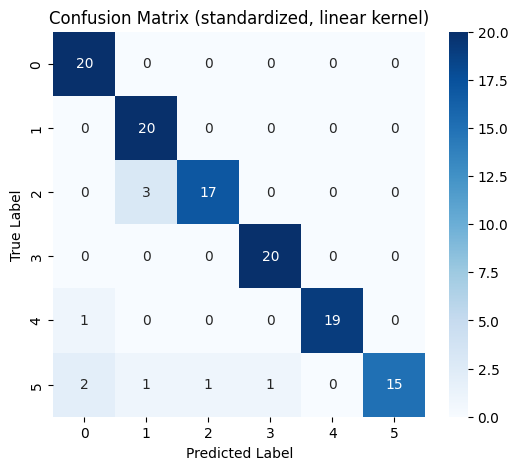

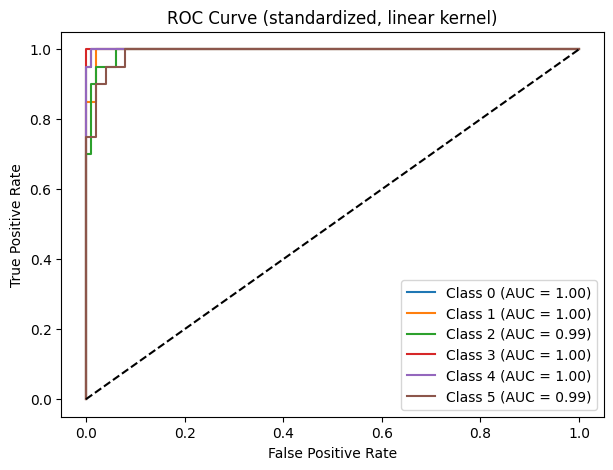

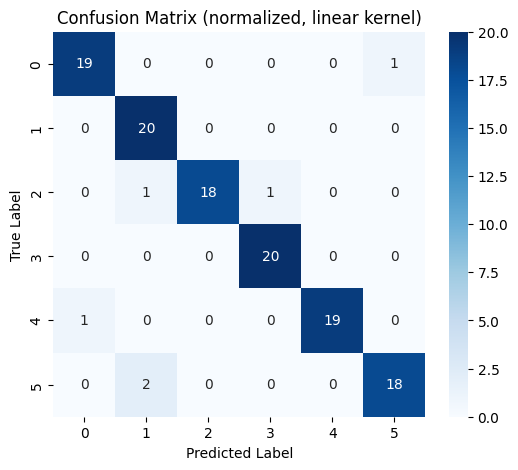

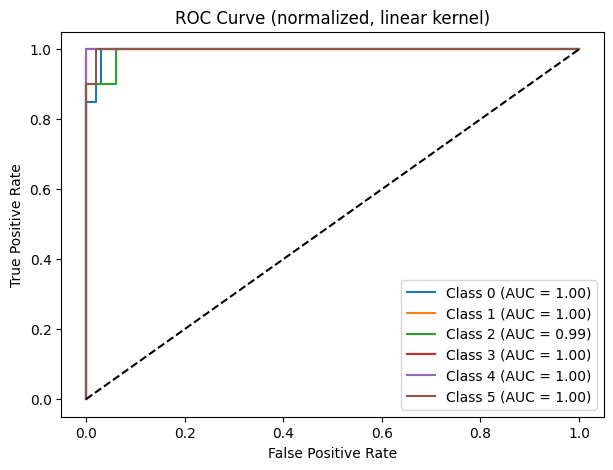

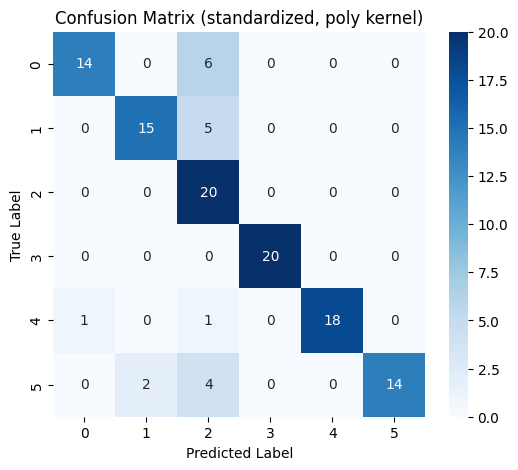

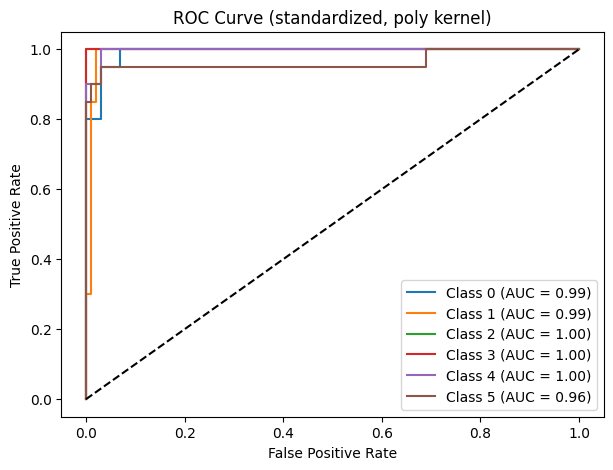

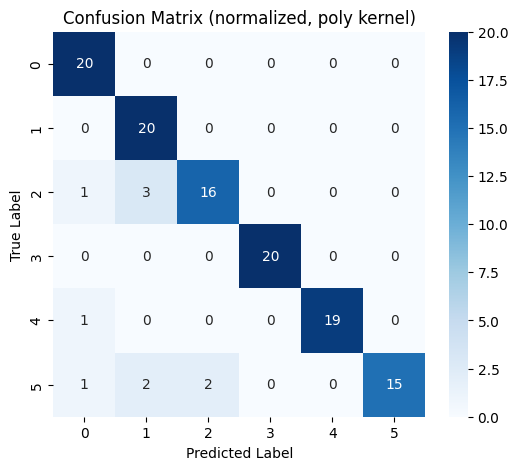

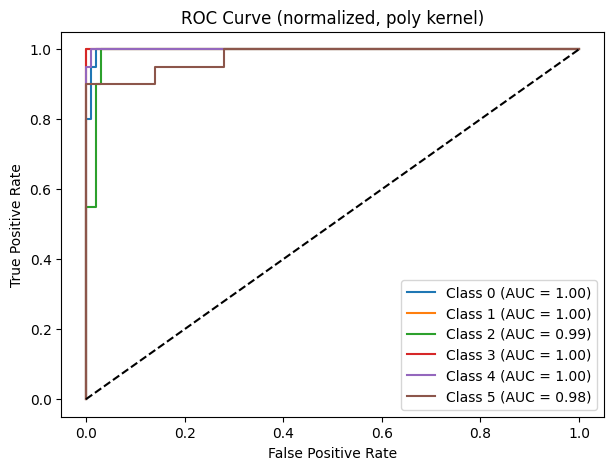

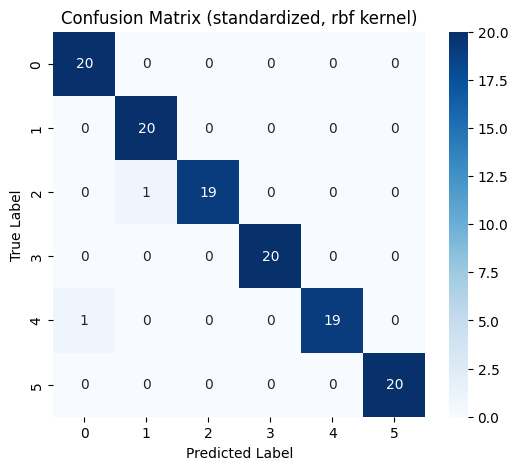

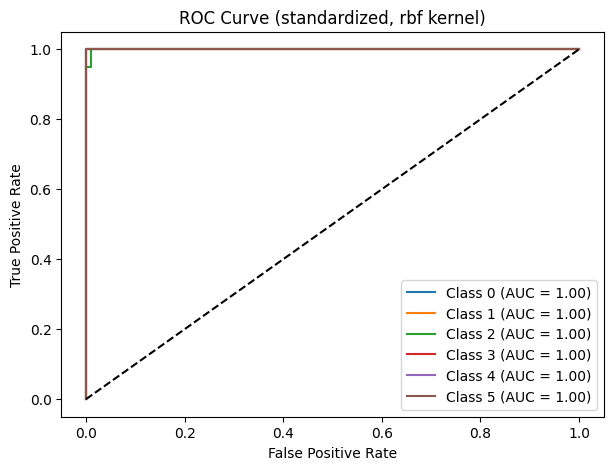

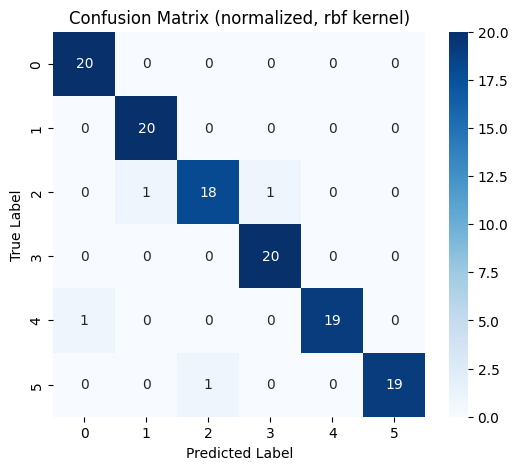

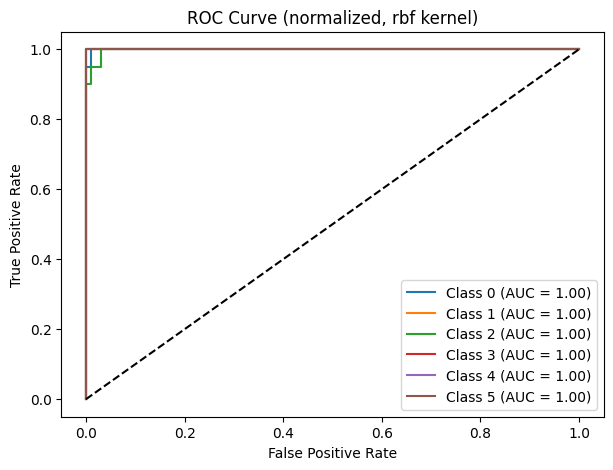

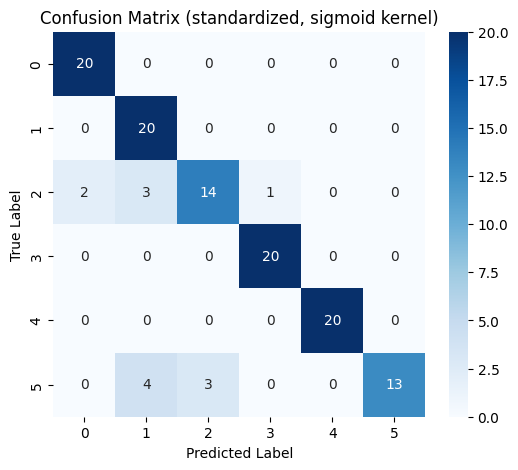

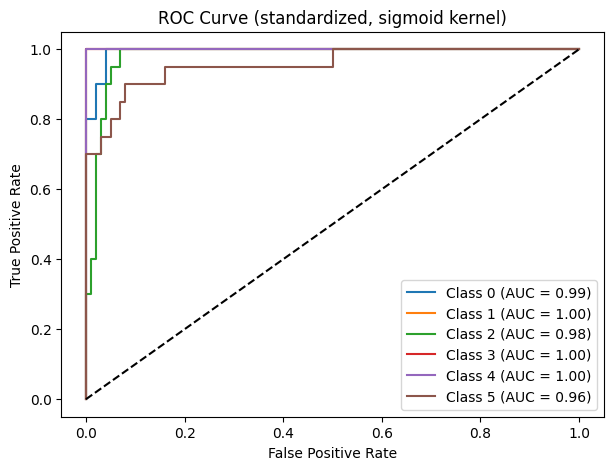

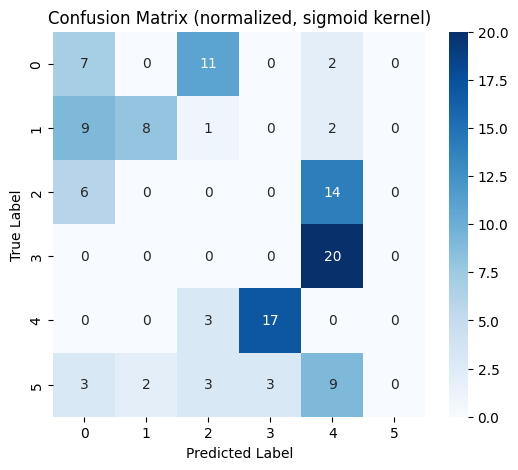

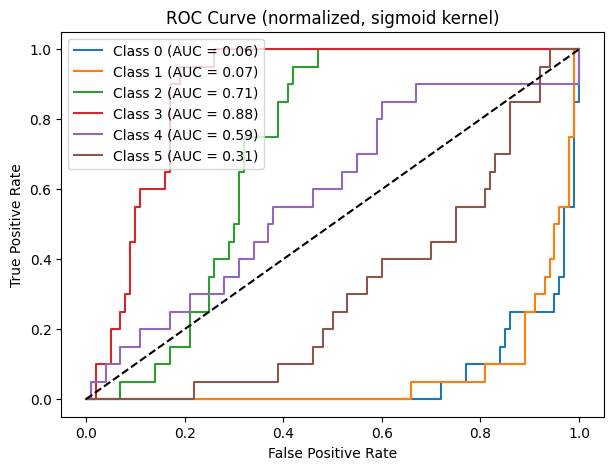

{'standardized': {'linear': {'accuracy': 0.925, 'f1_score': 0.9235286494891832, 'confusion_matrix': array([[20,  0,  0,  0,  0,  0],
       [ 0, 20,  0,  0,  0,  0],
       [ 0,  3, 17,  0,  0,  0],
       [ 0,  0,  0, 20,  0,  0],
       [ 1,  0,  0,  0, 19,  0],
       [ 2,  1,  1,  1,  0, 15]], dtype=int64)}, 'poly': {'accuracy': 0.8416666666666667, 'f1_score': 0.8493323929856438, 'confusion_matrix': array([[14,  0,  6,  0,  0,  0],
       [ 0, 15,  5,  0,  0,  0],
       [ 0,  0, 20,  0,  0,  0],
       [ 0,  0,  0, 20,  0,  0],
       [ 1,  0,  1,  0, 18,  0],
       [ 0,  2,  4,  0,  0, 14]], dtype=int64)}, 'rbf': {'accuracy': 0.9833333333333333, 'f1_score': 0.9833229101521784, 'confusion_matrix': array([[20,  0,  0,  0,  0,  0],
       [ 0, 20,  0,  0,  0,  0],
       [ 0,  1, 19,  0,  0,  0],
       [ 0,  0,  0, 20,  0,  0],
       [ 1,  0,  0,  0, 19,  0],
       [ 0,  0,  0,  0,  0, 20]], dtype=int64)}, 'sigmoid': {'accuracy': 0.8916666666666667, 'f1_score': 0.887281680483548

In [63]:
# Define kernels
kernels = ["linear", "poly", "rbf", "sigmoid"]

# Convert labels to one-hot encoding for ROC curve calculation
classes = np.unique(y_train)
y_train_bin = label_binarize(y_train, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_train_bin.shape[1]

# Store results
results = {"standardized": {}, "normalized": {}}

def plot_roc_curve(y_test_bin, y_score, title):
    plt.figure(figsize=(7, 5))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

# Train and evaluate models
for kernel in kernels:
    for data_type, (X_train, X_test) in zip(["standardized", "normalized"], 
                                           [(X_train_standardized, X_test_standardized), (X_train_normalized, X_test_normalized)]):
        
        # Train model
        model = SVC(kernel=kernel, probability=True, random_state=42)
        model.fit(X_train, y_train)
        
        # Predictions
        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)
        
        # Compute metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="weighted")
        cm = confusion_matrix(y_test, y_pred)
        
        # Store results
        results[data_type][kernel] = {"accuracy": accuracy, "f1_score": f1, "confusion_matrix": cm}
        
        # Plot confusion matrix
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title(f"Confusion Matrix ({data_type}, {kernel} kernel)")
        plt.show()
        
        # Plot ROC Curve
        plot_roc_curve(y_test_bin, y_score, f"ROC Curve ({data_type}, {kernel} kernel)")

# Print accuracy and F1-score results
print(results)


### KNN

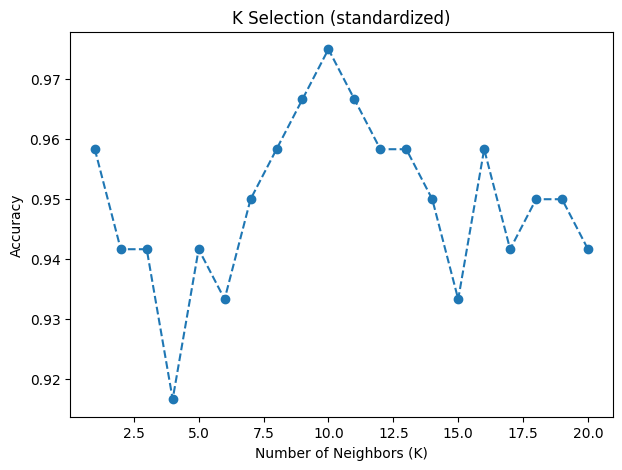

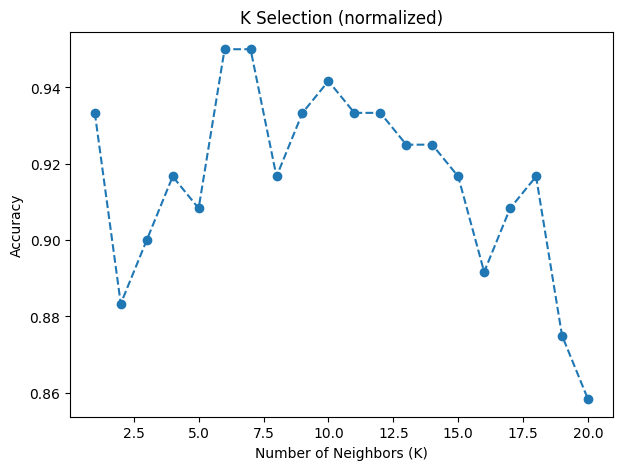

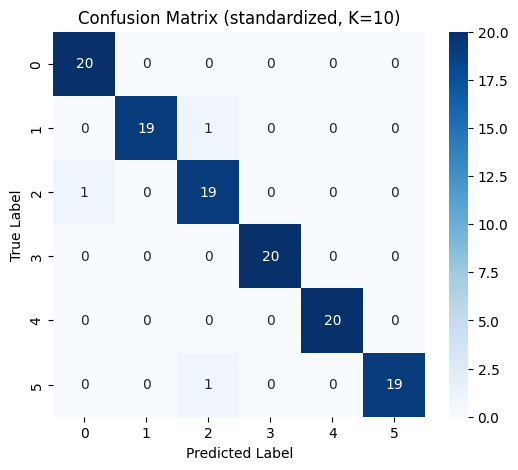

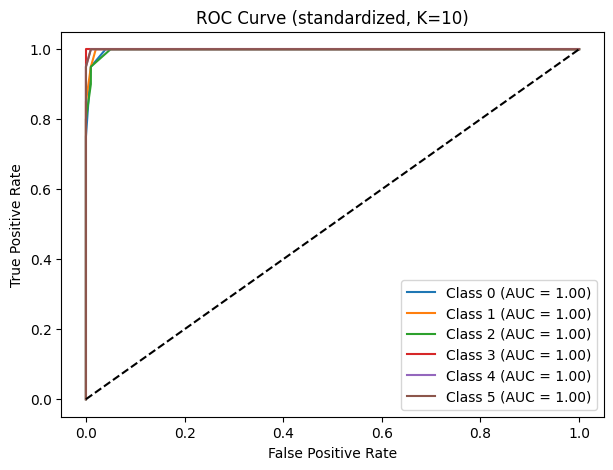

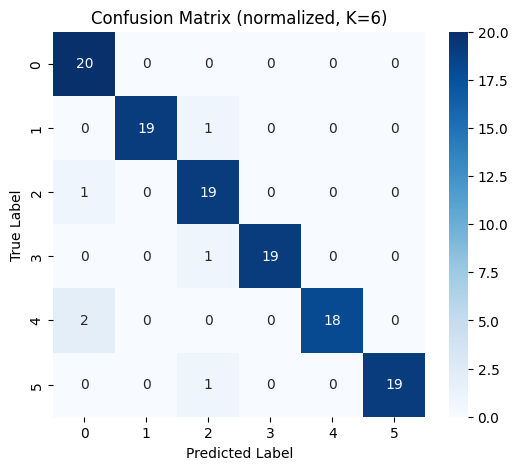

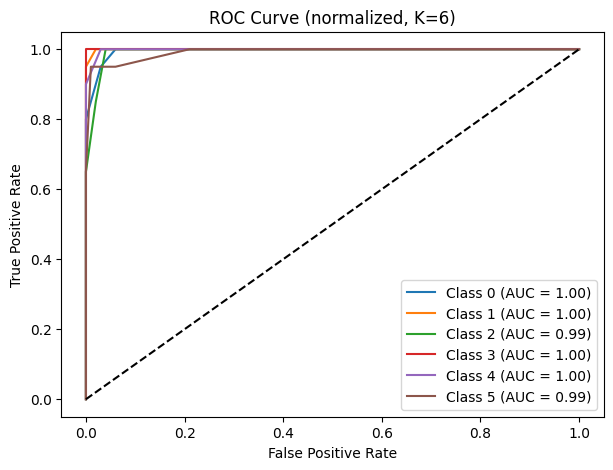

{'standardized': {'best_k': 10,
  'accuracy': 0.975,
  'f1_score': 0.9751928288513655,
  'confusion_matrix': array([[20,  0,  0,  0,  0,  0],
         [ 0, 19,  1,  0,  0,  0],
         [ 1,  0, 19,  0,  0,  0],
         [ 0,  0,  0, 20,  0,  0],
         [ 0,  0,  0,  0, 20,  0],
         [ 0,  0,  1,  0,  0, 19]], dtype=int64)},
 'normalized': {'best_k': 6,
  'accuracy': 0.95,
  'f1_score': 0.9509066345051658,
  'confusion_matrix': array([[20,  0,  0,  0,  0,  0],
         [ 0, 19,  1,  0,  0,  0],
         [ 1,  0, 19,  0,  0,  0],
         [ 0,  0,  1, 19,  0,  0],
         [ 2,  0,  0,  0, 18,  0],
         [ 0,  0,  1,  0,  0, 19]], dtype=int64)}}

In [64]:

# Define range for K values
k_values = range(1, 21)

# Store results for K selection
accuracy_scores = {"standardized": [], "normalized": []}

# Binarize labels for ROC curve
classes = np.unique(y_train)
y_train_bin = label_binarize(y_train, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_train_bin.shape[1]

# Function to plot ROC Curve
def plot_roc_curve(y_test_bin, y_score, title):
    plt.figure(figsize=(7, 5))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

# Find the best K for both datasets
best_k = {}

for data_type, (X_train, X_test) in zip(["standardized", "normalized"], [(X_train_standardized, X_test_standardized), (X_train_normalized, X_test_normalized)]):
    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        accuracy_scores[data_type].append(accuracy)
    
    # Find best K
    best_k[data_type] = k_values[np.argmax(accuracy_scores[data_type])]

    # Plot K vs Accuracy
    plt.figure(figsize=(7, 5))
    plt.plot(k_values, accuracy_scores[data_type], marker='o', linestyle='dashed')
    plt.xlabel("Number of Neighbors (K)")
    plt.ylabel("Accuracy")
    plt.title(f"K Selection ({data_type})")
    plt.show()

# Train final models with best K and evaluate
results = {}

for data_type, (X_train, X_test) in zip(["standardized", "normalized"], [(X_train_standardized, X_test_standardized), (X_train_normalized, X_test_normalized)]):
    k_optimal = best_k[data_type]
    model = KNeighborsClassifier(n_neighbors=k_optimal)
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)

    results[data_type] = {"best_k": k_optimal, "accuracy": accuracy, "f1_score": f1, "confusion_matrix": cm}

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({data_type}, K={k_optimal})")
    plt.show()

    # Plot ROC Curve
    plot_roc_curve(y_test_bin, y_score, f"ROC Curve ({data_type}, K={k_optimal})")

# Display results
results


### Random Forest

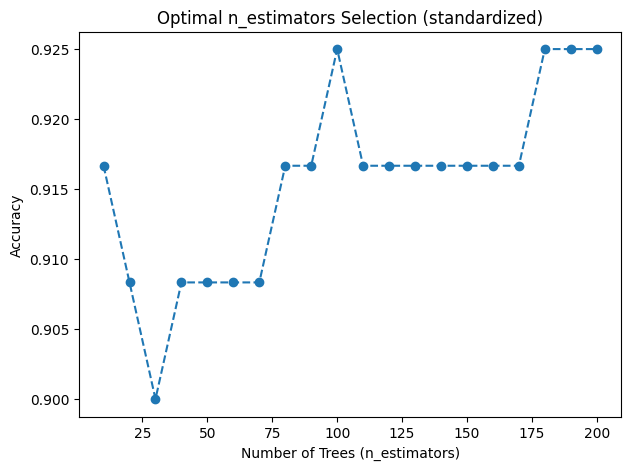

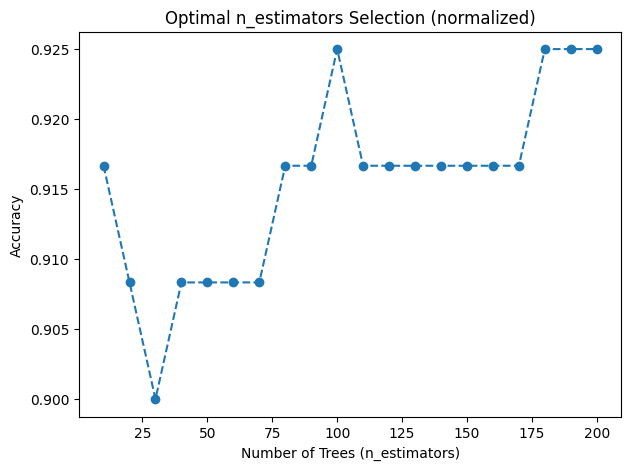

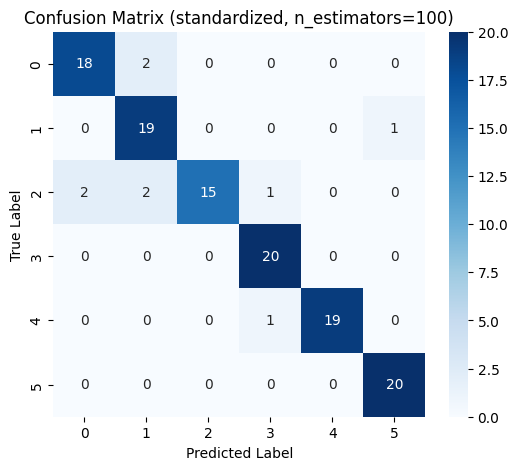

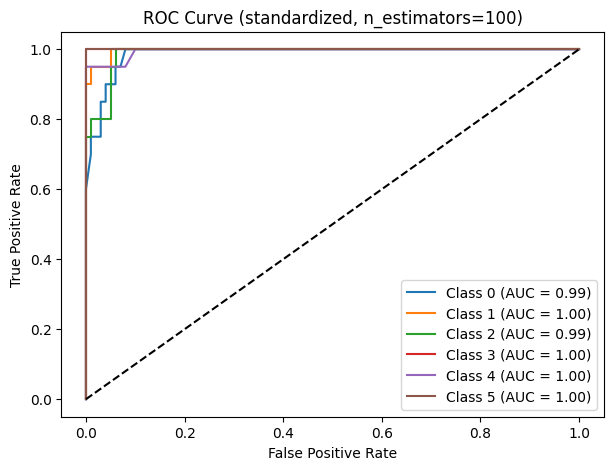

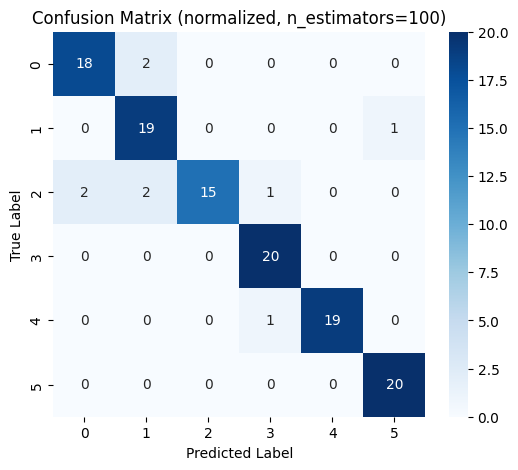

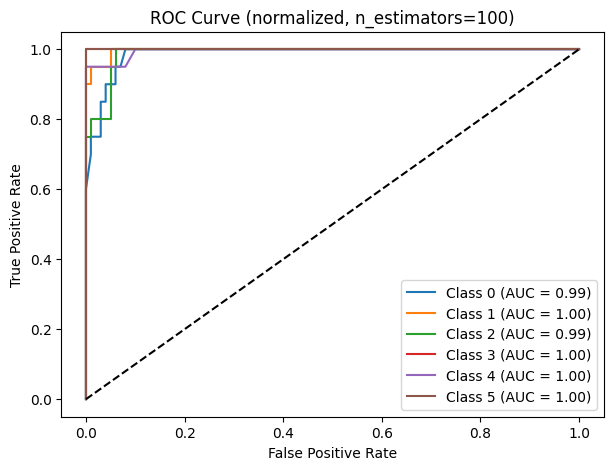

{'standardized': {'best_n_estimators': 100,
  'accuracy': 0.925,
  'f1_score': 0.9238689117021506,
  'confusion_matrix': array([[18,  2,  0,  0,  0,  0],
         [ 0, 19,  0,  0,  0,  1],
         [ 2,  2, 15,  1,  0,  0],
         [ 0,  0,  0, 20,  0,  0],
         [ 0,  0,  0,  1, 19,  0],
         [ 0,  0,  0,  0,  0, 20]], dtype=int64)},
 'normalized': {'best_n_estimators': 100,
  'accuracy': 0.925,
  'f1_score': 0.9238689117021506,
  'confusion_matrix': array([[18,  2,  0,  0,  0,  0],
         [ 0, 19,  0,  0,  0,  1],
         [ 2,  2, 15,  1,  0,  0],
         [ 0,  0,  0, 20,  0,  0],
         [ 0,  0,  0,  1, 19,  0],
         [ 0,  0,  0,  0,  0, 20]], dtype=int64)}}

In [65]:
# Define range for n_estimators
n_estimators_range = range(10, 201, 10)

# Store results for n_estimators selection
accuracy_scores = {"standardized": [], "normalized": []}

# Binarize labels for ROC curve
classes = np.unique(y_train)
y_train_bin = label_binarize(y_train, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_train_bin.shape[1]

# Function to plot ROC Curve
def plot_roc_curve(y_test_bin, y_score, title):
    plt.figure(figsize=(7, 5))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

# Find the best n_estimators for both datasets
best_n_estimators = {}

for data_type, (X_train, X_test) in zip(["standardized", "normalized"], [(X_train_standardized, X_test_standardized), (X_train_normalized, X_test_normalized)]):
    for n in n_estimators_range:
        model = RandomForestClassifier(n_estimators=n, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        accuracy_scores[data_type].append(accuracy)
    
    # Find best n_estimators
    best_n_estimators[data_type] = n_estimators_range[np.argmax(accuracy_scores[data_type])]

    # Plot n_estimators vs Accuracy
    plt.figure(figsize=(7, 5))
    plt.plot(n_estimators_range, accuracy_scores[data_type], marker='o', linestyle='dashed')
    plt.xlabel("Number of Trees (n_estimators)")
    plt.ylabel("Accuracy")
    plt.title(f"Optimal n_estimators Selection ({data_type})")
    plt.show()

# Train final models with best n_estimators and evaluate
results = {}

for data_type, (X_train, X_test) in zip(["standardized", "normalized"], [(X_train_standardized, X_test_standardized), (X_train_normalized, X_test_normalized)]):
    n_optimal = best_n_estimators[data_type]
    model = RandomForestClassifier(n_estimators=n_optimal, random_state=42)
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)

    results[data_type] = {"best_n_estimators": n_optimal, "accuracy": accuracy, "f1_score": f1, "confusion_matrix": cm}

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({data_type}, n_estimators={n_optimal})")
    plt.show()

    # Plot ROC Curve
    plot_roc_curve(y_test_bin, y_score, f"ROC Curve ({data_type}, n_estimators={n_optimal})")

# Display results
results


## Multi-Class MLP
We design a Neural Network with an output layer size equal to the number of speakers ($N=6$). We use `CrossEntropyLoss` which is suitable for multi-class classification problems.

Using device: cuda


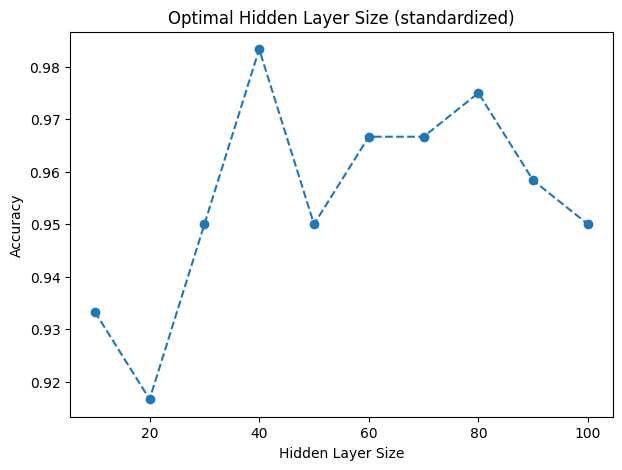

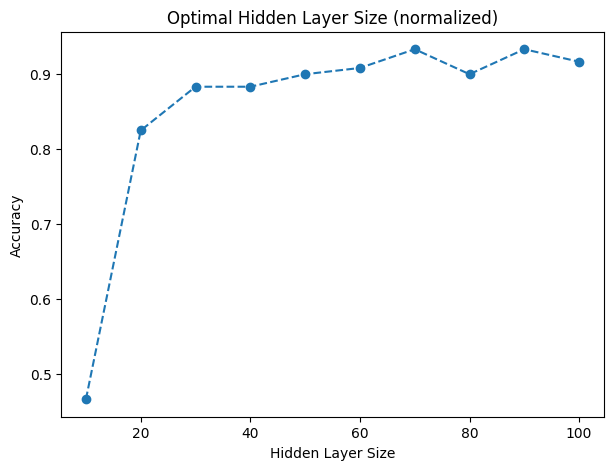

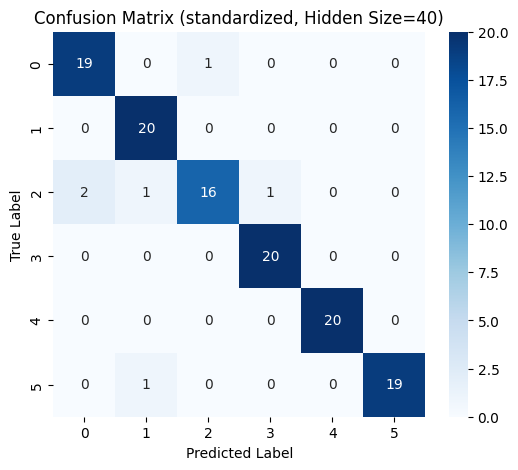

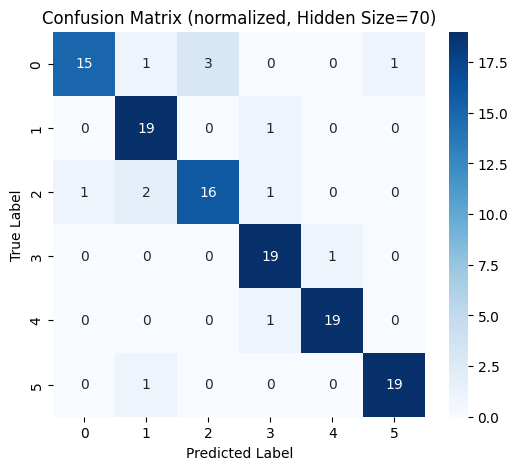

{'standardized': {'best_hidden_size': 40, 'accuracy': 0.95, 'f1_score': 0.9490073026658392, 'confusion_matrix': array([[19,  0,  1,  0,  0,  0],
       [ 0, 20,  0,  0,  0,  0],
       [ 2,  1, 16,  1,  0,  0],
       [ 0,  0,  0, 20,  0,  0],
       [ 0,  0,  0,  0, 20,  0],
       [ 0,  1,  0,  0,  0, 19]], dtype=int64)}, 'normalized': {'best_hidden_size': 70, 'accuracy': 0.8916666666666667, 'f1_score': 0.8903881648067694, 'confusion_matrix': array([[15,  1,  3,  0,  0,  1],
       [ 0, 19,  0,  1,  0,  0],
       [ 1,  2, 16,  1,  0,  0],
       [ 0,  0,  0, 19,  1,  0],
       [ 0,  0,  0,  1, 19,  0],
       [ 0,  1,  0,  0,  0, 19]], dtype=int64)}}


In [ ]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert data to PyTorch tensors
X_train_standardized_tensor = torch.tensor(X_train_standardized.values, dtype=torch.float32).to(device)
X_test_standardized_tensor = torch.tensor(X_test_standardized.values, dtype=torch.float32).to(device)
X_train_normalized_tensor = torch.tensor(X_train_normalized.values, dtype=torch.float32).to(device)
X_test_normalized_tensor = torch.tensor(X_test_normalized.values, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

# MLP Model
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Training function
def train_model(model, train_loader, criterion, optimizer, epochs=50):
    model.train()
    for epoch in range(epochs):
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

# Evaluation function
def evaluate_model(model, X_test_tensor, y_test_tensor):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test_tensor)
        _, y_pred = torch.max(outputs, 1)
        y_pred = y_pred.cpu().numpy()
        y_test = y_test_tensor.cpu().numpy()

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)

    return accuracy, f1, cm, y_pred

# Hyperparameter tuning
hidden_sizes = range(10, 101, 10)
accuracy_scores = {"standardized": [], "normalized": []}
best_hidden_size = {}

data_types = ["standardized", "normalized"]
datasets = [(X_train_standardized_tensor, X_test_standardized_tensor, y_train_tensor, y_test_tensor),
            (X_train_normalized_tensor, X_test_normalized_tensor, y_train_tensor, y_test_tensor)]

for data_type, (X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor) in zip(data_types, datasets):
    input_size = X_train_tensor.shape[1]
    output_size = len(torch.unique(y_train_tensor))
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

    for hidden_size in hidden_sizes:
        model = MLP(input_size, hidden_size, output_size).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        train_model(model, train_loader, criterion, optimizer)
        accuracy, _, _, _ = evaluate_model(model, X_test_tensor, y_test_tensor)
        accuracy_scores[data_type].append(accuracy)

    best_hidden_size[data_type] = hidden_sizes[np.argmax(accuracy_scores[data_type])]
    plt.figure(figsize=(7, 5))
    plt.plot(hidden_sizes, accuracy_scores[data_type], marker='o', linestyle='dashed')
    plt.xlabel("Hidden Layer Size")
    plt.ylabel("Accuracy")
    plt.title(f"Optimal Hidden Layer Size ({data_type})")
    plt.show()

# Train final models and evaluate
results = {}
for data_type, (X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor) in zip(data_types, datasets):
    input_size = X_train_tensor.shape[1]
    output_size = len(torch.unique(y_train_tensor))
    hidden_size = best_hidden_size[data_type]

    model = MLP(input_size, hidden_size, output_size).to(device)
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_model(model, train_loader, criterion, optimizer)
    
    accuracy, f1, cm, y_pred = evaluate_model(model, X_test_tensor, y_test_tensor)
    results[data_type] = {"best_hidden_size": hidden_size, "accuracy": accuracy, "f1_score": f1, "confusion_matrix": cm}
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=torch.unique(y_train_tensor).cpu().numpy(), yticklabels=torch.unique(y_train_tensor).cpu().numpy())
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({data_type}, Hidden Size={hidden_size})")
    plt.show()

# Print results
print(results)
